In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [2]:
clean_df = pd.read_csv("../data/processed/cleaned_online_retail_with_skew_features.csv")

clean_df["invoice_date"] = pd.to_datetime(clean_df["invoice_date"])
clean_df["date"] = pd.to_datetime(clean_df["date"])

print("Clean data shape:", clean_df.shape)

clean_df.head()

Clean data shape: (524878, 24)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,customer_id_missing,is_cancelled,...,day,day_of_week,hour,year_month,log_quantity,log_unit_price,log_total_amount,quantity_capped,unit_price_capped,total_amount_capped
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,0,...,1,Wednesday,8,2010-12,1.945910,1.266948,2.791165,6.0,2.55,15.30
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,...,1,Wednesday,8,2010-12,1.945910,1.479329,3.060583,6.0,3.39,20.34
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,0,...,1,Wednesday,8,2010-12,2.197225,1.321756,3.135494,8.0,2.75,22.00
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,...,1,Wednesday,8,2010-12,1.945910,1.479329,3.060583,6.0,3.39,20.34
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,0,...,1,Wednesday,8,2010-12,1.945910,1.479329,3.060583,6.0,3.39,20.34


In [3]:
daily_demand = (
    clean_df.groupby("date")
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("total_amount", "sum"),
        total_revenue_capped=("total_amount_capped", "sum"),
        total_orders=("invoice_no", "nunique"),
        unique_products=("stock_code", "nunique"),
        unique_customers=("customer_id", "nunique")
    )
    .reset_index()
)

daily_demand = daily_demand.sort_values("date")

print("Daily demand shape:", daily_demand.shape)

daily_demand.head()

Daily demand shape: (305, 7)


,date,total_quantity,total_revenue,total_revenue_capped,total_orders,unique_products,unique_customers
0,2010-12-01,26818,58776.79,50760.50,127,1340,95
1,2010-12-02,31264,47629.42,40699.01,142,923,99
2,2010-12-03,16158,46898.63,39814.34,68,1133,50
3,2010-12-05,16242,31364.63,30349.37,88,1142,75
4,2010-12-06,21619,54624.15,48345.82,102,1471,82


In [4]:
daily_demand = (
    clean_df.groupby("date")
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("total_amount", "sum"),
        total_revenue_capped=("total_amount_capped", "sum"),
        total_orders=("invoice_no", "nunique"),
        unique_products=("stock_code", "nunique"),
        unique_customers=("customer_id", "nunique")
    )
    .reset_index()
)

daily_demand = daily_demand.sort_values("date")

print("Daily demand shape:", daily_demand.shape)

daily_demand.head()

Daily demand shape: (305, 7)


,date,total_quantity,total_revenue,total_revenue_capped,total_orders,unique_products,unique_customers
0,2010-12-01,26818,58776.79,50760.50,127,1340,95
1,2010-12-02,31264,47629.42,40699.01,142,923,99
2,2010-12-03,16158,46898.63,39814.34,68,1133,50
3,2010-12-05,16242,31364.63,30349.37,88,1142,75
4,2010-12-06,21619,54624.15,48345.82,102,1471,82


In [5]:
full_date_range = pd.date_range(
    start=daily_demand["date"].min(),
    end=daily_demand["date"].max(),
    freq="D"
)

missing_dates = set(full_date_range) - set(daily_demand["date"])

print("Start date:", daily_demand["date"].min())
print("End date:", daily_demand["date"].max())
print("Expected days:", len(full_date_range))
print("Available days:", daily_demand.shape[0])
print("Missing dates:", len(missing_dates))

Start date: 2010-12-01 00:00:00
End date: 2011-12-09 00:00:00
Expected days: 374
Available days: 305
Missing dates: 69


In [6]:
daily_demand = (
    daily_demand
    .set_index("date")
    .reindex(full_date_range)
    .rename_axis("date")
    .reset_index()
)

daily_demand[[
    "total_quantity",
    "total_revenue",
    "total_revenue_capped",
    "total_orders",
    "unique_products",
    "unique_customers"
]] = daily_demand[[
    "total_quantity",
    "total_revenue",
    "total_revenue_capped",
    "total_orders",
    "unique_products",
    "unique_customers"
]].fillna(0)

print("Daily demand shape after filling dates:", daily_demand.shape)

daily_demand.head()

Daily demand shape after filling dates: (374, 7)


,date,total_quantity,total_revenue,total_revenue_capped,total_orders,unique_products,unique_customers
0,2010-12-01,26818.0,58776.79,50760.50,127.0,1340.0,95.0
1,2010-12-02,31264.0,47629.42,40699.01,142.0,923.0,99.0
2,2010-12-03,16158.0,46898.63,39814.34,68.0,1133.0,50.0
3,2010-12-04,0.0,0.00,0.00,0.0,0.0,0.0
4,2010-12-05,16242.0,31364.63,30349.37,88.0,1142.0,75.0


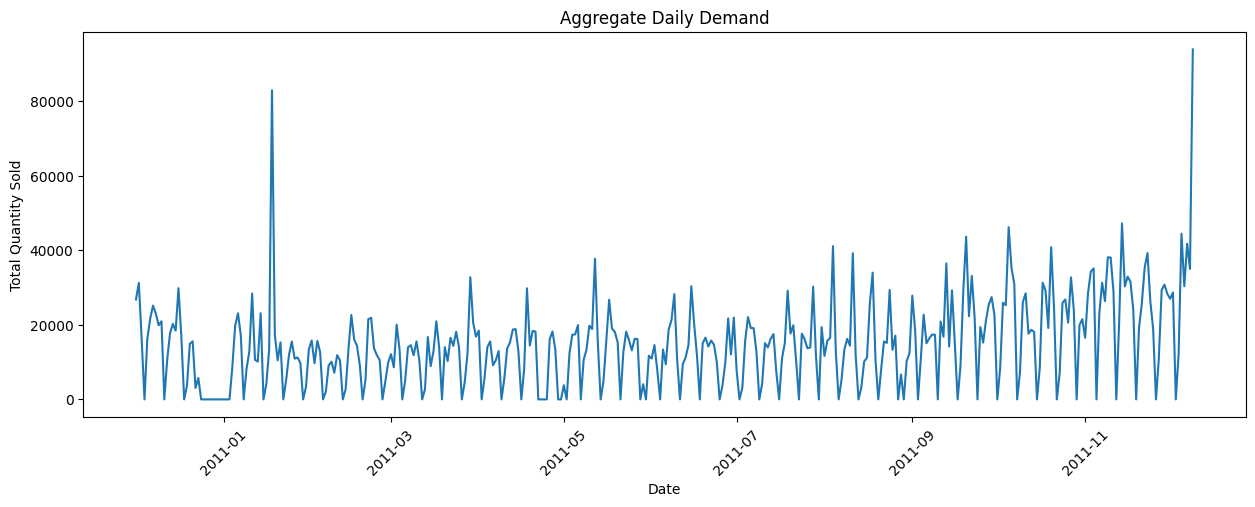

In [7]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_demand["date"],
    daily_demand["total_quantity"]
)

plt.title("Aggregate Daily Demand")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)

plt.show()

In [8]:
daily_demand["total_quantity"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count      374.000000
mean     14899.518717
std      11931.618170
min          0.000000
25%       7005.750000
50%      14280.000000
75%      20267.750000
90%      29352.200000
95%      34557.600000
99%      44962.750000
max      93949.000000
Name: total_quantity, dtype: float64

In [9]:
demand_cap = daily_demand["total_quantity"].quantile(0.99)

daily_demand["total_quantity_capped"] = np.where(
    daily_demand["total_quantity"] > demand_cap,
    demand_cap,
    daily_demand["total_quantity"]
)

print("Demand cap value:", demand_cap)

daily_demand[["total_quantity", "total_quantity_capped"]].describe()

Demand cap value: 44962.74999999997


,total_quantity,total_quantity_capped
count,374.000000,374.000000
mean,14899.518717,14657.486631
std,11931.618170,10834.674358
min,0.000000,0.000000
25%,7005.750000,7005.750000
50%,14280.000000,14280.000000
75%,20267.750000,20267.750000
max,93949.000000,44962.750000


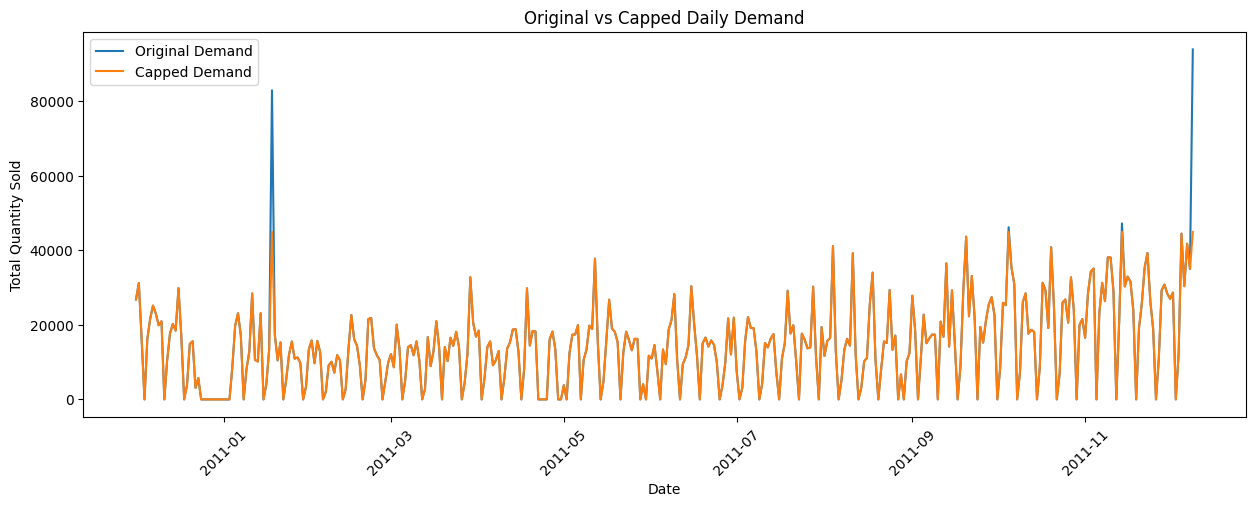

In [10]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily_demand["date"],
    daily_demand["total_quantity"],
    label="Original Demand"
)

plt.plot(
    daily_demand["date"],
    daily_demand["total_quantity_capped"],
    label="Capped Demand"
)

plt.title("Original vs Capped Daily Demand")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [11]:
forecast_data = daily_demand[[
    "date",
    "total_quantity",
    "total_quantity_capped",
    "total_revenue",
    "total_orders",
    "unique_products",
    "unique_customers"
]].copy()

forecast_data = forecast_data.sort_values("date")

forecast_data.head()

,date,total_quantity,total_quantity_capped,total_revenue,total_orders,unique_products,unique_customers
0,2010-12-01,26818.0,26818.0,58776.79,127.0,1340.0,95.0
1,2010-12-02,31264.0,31264.0,47629.42,142.0,923.0,99.0
2,2010-12-03,16158.0,16158.0,46898.63,68.0,1133.0,50.0
3,2010-12-04,0.0,0.0,0.00,0.0,0.0,0.0
4,2010-12-05,16242.0,16242.0,31364.63,88.0,1142.0,75.0


In [12]:
train_size = int(len(forecast_data) * 0.8)

train_df = forecast_data.iloc[:train_size].copy()
test_df = forecast_data.iloc[train_size:].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

Train shape: (299, 7)
Test shape: (75, 7)
Train date range: 2010-12-01 00:00:00 to 2011-09-25 00:00:00
Test date range: 2011-09-26 00:00:00 to 2011-12-09 00:00:00


In [13]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    smape = np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100

    return mae, rmse, smape

TIME SERIES ANALYSIS

In [14]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

In [15]:
ts_data = daily_demand.set_index("date")["total_quantity"]

ts_data = ts_data.asfreq("D")

ts_data = ts_data.fillna(0)

ts_data.head()

date
2010-12-01    26818.0
2010-12-02    31264.0
2010-12-03    16158.0
2010-12-04        0.0
2010-12-05    16242.0
Freq: D, Name: total_quantity, dtype: float64

In [16]:
adf_result = adfuller(ts_data)

print("ADF Test Results")
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(key, ":", value)

if adf_result[1] <= 0.05:
    print("\nConclusion: Series is likely stationary according to ADF test.")
else:
    print("\nConclusion: Series is likely non-stationary according to ADF test.")

ADF Test Results
ADF Statistic: -0.99307164028736
p-value: 0.7557828658169337
Critical Values:
1% : -3.448645946352023
5% : -2.869602139060357
10% : -2.5710650077160495

Conclusion: Series is likely non-stationary according to ADF test.


In [17]:
kpss_result = kpss(ts_data, regression="c", nlags="auto")

print("KPSS Test Results")
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])
print("Critical Values:")

for key, value in kpss_result[3].items():
    print(key, ":", value)

if kpss_result[1] >= 0.05:
    print("\nConclusion: Series is likely stationary according to KPSS test.")
else:
    print("\nConclusion: Series is likely non-stationary according to KPSS test.")

KPSS Test Results
KPSS Statistic: 2.7698337547083645
p-value: 0.01
Critical Values:
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739

Conclusion: Series is likely non-stationary according to KPSS test.


C:\Users\swapn\AppData\Local\Temp\ipykernel_24600\904942445.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts_data, regression="c", nlags="auto")


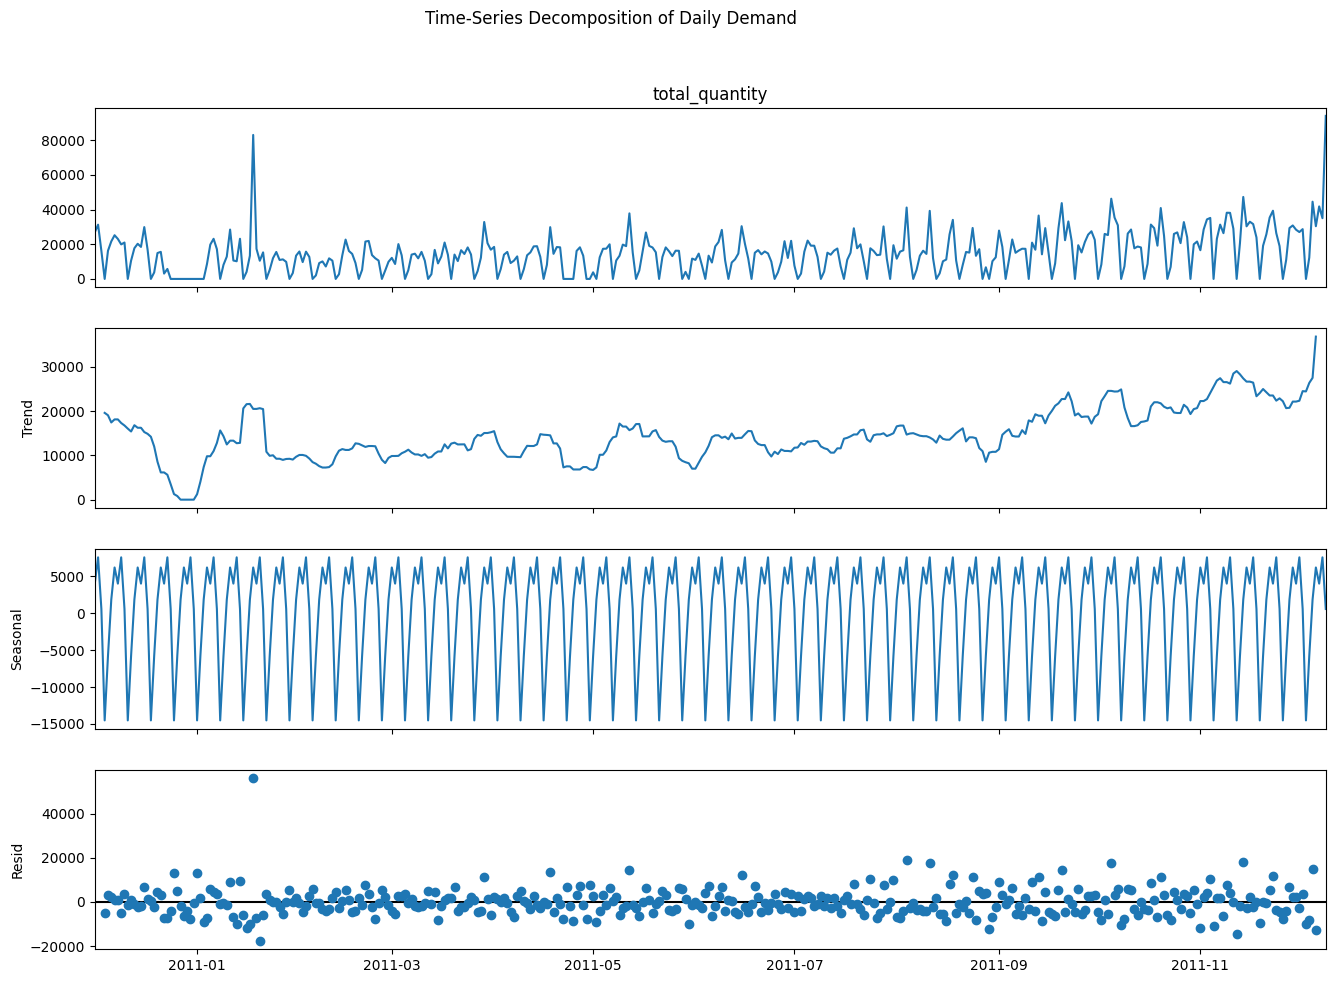

In [18]:
decomposition = seasonal_decompose(
    ts_data,
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(15, 10)

plt.suptitle("Time-Series Decomposition of Daily Demand", y=1.02)

plt.show()

In [19]:
stationarity_summary = pd.DataFrame({
    "test": ["ADF", "KPSS"],
    "statistic": [adf_result[0], kpss_result[0]],
    "p_value": [adf_result[1], kpss_result[1]],
    "interpretation": [
        "Stationary" if adf_result[1] <= 0.05 else "Non-stationary",
        "Stationary" if kpss_result[1] >= 0.05 else "Non-stationary"
    ]
})

stationarity_summary.to_csv(
    "../data/processed/time_series_stationarity_summary.csv",
    index=False
)

stationarity_summary

,test,statistic,p_value,interpretation
0,ADF,-0.993072,0.755783,Non-stationary
1,KPSS,2.769834,0.010000,Non-stationary


In [20]:
ts_diff = ts_data.diff().dropna()

adf_diff = adfuller(ts_diff)

print("Differenced Series ADF")
print("Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

Differenced Series ADF
Statistic: -7.0650608863984035
p-value: 5.105860536758945e-10


After observing above p values we can determine that First-order differencing makes the series stationary.

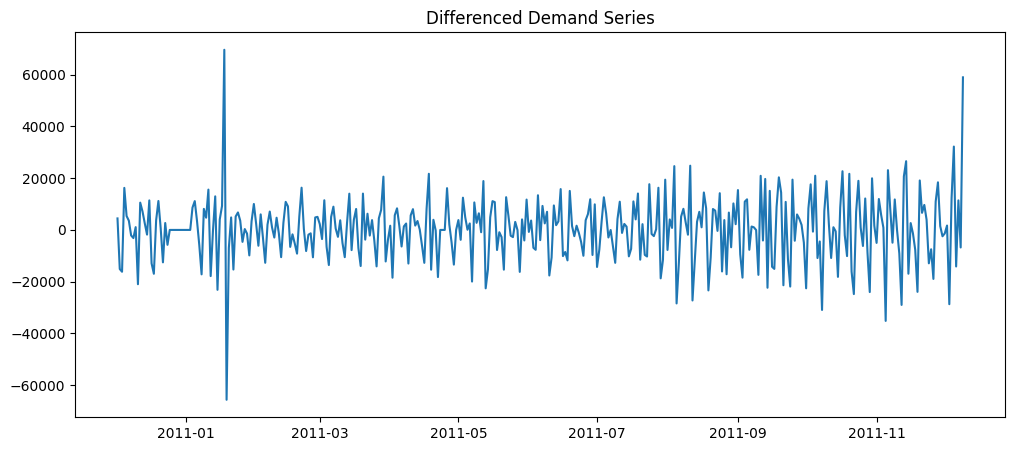

In [21]:
plt.figure(figsize=(12,5))

plt.plot(ts_diff)

plt.title("Differenced Demand Series")

plt.show()

In [22]:
last_train_value = train_df["total_quantity_capped"].iloc[-1]

test_df["naive_prediction"] = last_train_value

naive_mae, naive_rmse, naive_smape = calculate_metrics(
    test_df["total_quantity_capped"].values,
    test_df["naive_prediction"].values
)

print("Naive Baseline Results")
print("MAE:", naive_mae)
print("RMSE:", naive_rmse)
print("SMAPE:", naive_smape)

Naive Baseline Results
MAE: 11003.23
RMSE: 13091.293326832401
SMAPE: 61.45335151587704


In [23]:
moving_avg_window = 7

moving_avg_value = train_df["total_quantity_capped"].tail(
    moving_avg_window
).mean()

test_df["moving_avg_prediction"] = moving_avg_value

ma_mae, ma_rmse, ma_smape = calculate_metrics(
    test_df["total_quantity_capped"].values,
    test_df["moving_avg_prediction"].values
)

print("Moving Average Baseline Results")
print("MAE:", ma_mae)
print("RMSE:", ma_rmse)
print("SMAPE:", ma_smape)

Moving Average Baseline Results
MAE: 9817.898571428572
RMSE: 12549.801714065601
SMAPE: 53.12699087067346


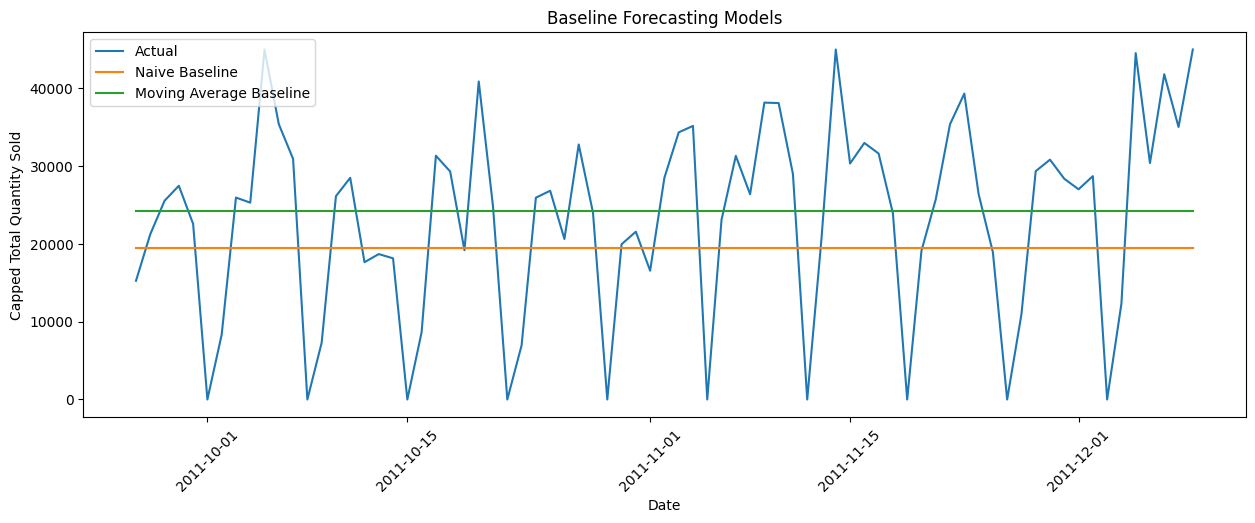

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_df["date"],
    test_df["total_quantity_capped"],
    label="Actual"
)

plt.plot(
    test_df["date"],
    test_df["naive_prediction"],
    label="Naive Baseline"
)

plt.plot(
    test_df["date"],
    test_df["moving_avg_prediction"],
    label="Moving Average Baseline"
)

plt.title("Baseline Forecasting Models")
plt.xlabel("Date")
plt.ylabel("Capped Total Quantity Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

# PROPHET MODEL

In [25]:
from prophet import Prophet

prophet_train = train_df.rename(
    columns={
        "date": "ds",
        "total_quantity_capped": "y"
    }
)[["ds", "y"]]

prophet_test = test_df.rename(
    columns={
        "date": "ds",
        "total_quantity_capped": "y"
    }
)[["ds", "y"]]

prophet_train.head()

,ds,y
0,2010-12-01,26818.0
1,2010-12-02,31264.0
2,2010-12-03,16158.0
3,2010-12-04,0.0
4,2010-12-05,16242.0


In [26]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,
    seasonality_prior_scale=10
)

prophet_model.fit(prophet_train)

17:06:00 - cmdstanpy - INFO - Chain [1] start processing
17:06:01 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
future = prophet_model.make_future_dataframe(
    periods=len(test_df),
    freq="D"
)

forecast = prophet_model.predict(future)

prophet_predictions = forecast.tail(len(test_df))["yhat"].values

prophet_predictions = np.maximum(prophet_predictions, 0)

test_df["prophet_prediction"] = prophet_predictions

prophet_mae, prophet_rmse, prophet_smape = calculate_metrics(
    test_df["total_quantity_capped"].values,
    test_df["prophet_prediction"].values
)

print("Prophet Results")
print("MAE:", prophet_mae)
print("RMSE:", prophet_rmse)
print("SMAPE:", prophet_smape)

Prophet Results
MAE: 13196.277969131286
RMSE: 16941.37642798565
SMAPE: 83.19125542132869


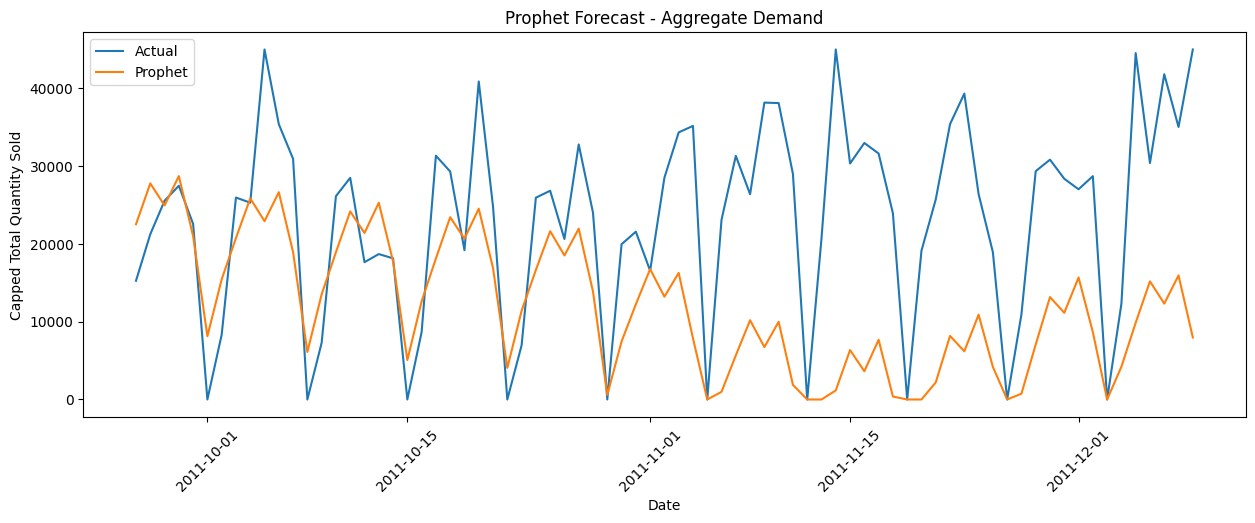

In [28]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_df["date"],
    test_df["total_quantity_capped"],
    label="Actual"
)

plt.plot(
    test_df["date"],
    test_df["prophet_prediction"],
    label="Prophet"
)

plt.title("Prophet Forecast - Aggregate Demand")
plt.xlabel("Date")
plt.ylabel("Capped Total Quantity Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

# LOG TRANFORMED PROPHET

In [29]:
prophet_train_log = train_df.copy()

prophet_train_log["y"] = np.log1p(
    prophet_train_log["total_quantity_capped"]
)

prophet_train_log = prophet_train_log.rename(
    columns={"date": "ds"}
)[["ds", "y"]]

prophet_train_log.head()

,ds,y
0,2010-12-01,10.196866
1,2010-12-02,10.350255
2,2010-12-03,9.690232
3,2010-12-04,0.000000
4,2010-12-05,9.695417


In [30]:
prophet_model_log = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=5
)

prophet_model_log.fit(prophet_train_log)

17:06:02 - cmdstanpy - INFO - Chain [1] start processing
17:06:02 - cmdstanpy - INFO - Chain [1] done processing


In [31]:
future_log = prophet_model_log.make_future_dataframe(
    periods=len(test_df),
    freq="D"
)

forecast_log = prophet_model_log.predict(future_log)

prophet_log_predictions = forecast_log.tail(len(test_df))["yhat"].values

prophet_log_predictions = np.expm1(prophet_log_predictions)

prophet_log_predictions = np.maximum(prophet_log_predictions, 0)

test_df["prophet_log_prediction"] = prophet_log_predictions

prophet_log_mae, prophet_log_rmse, prophet_log_smape = calculate_metrics(
    test_df["total_quantity_capped"].values,
    test_df["prophet_log_prediction"].values
)

print("Prophet Log Results")
print("MAE:", prophet_log_mae)
print("RMSE:", prophet_log_rmse)
print("SMAPE:", prophet_log_smape)

Prophet Log Results
MAE: 29133.86055331564
RMSE: 48293.16365874955
SMAPE: 125.35788189452369


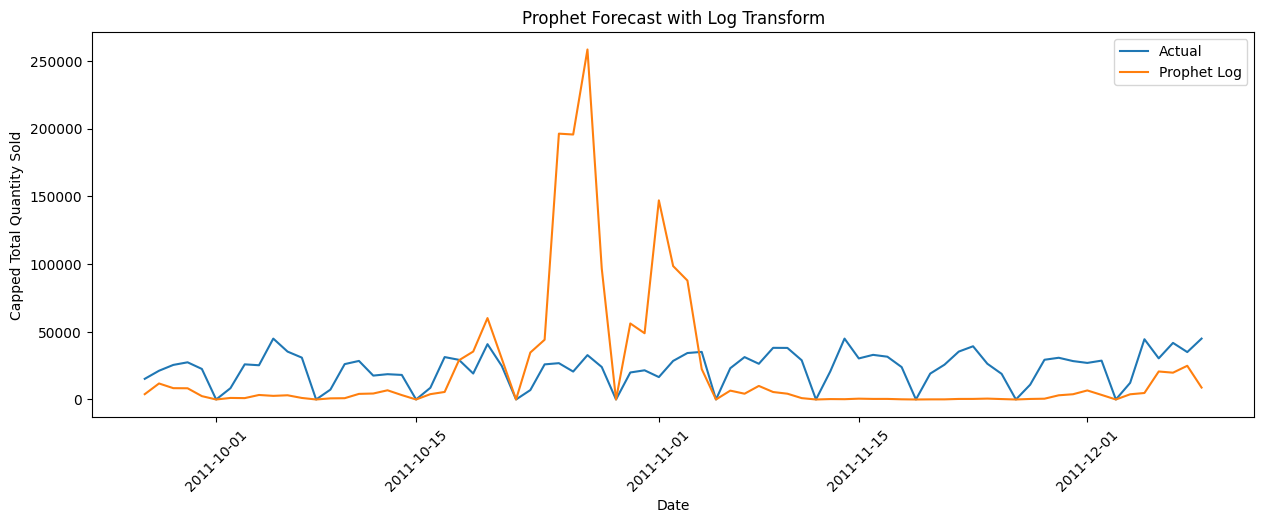

In [32]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_df["date"],
    test_df["total_quantity_capped"],
    label="Actual"
)

plt.plot(
    test_df["date"],
    test_df["prophet_log_prediction"],
    label="Prophet Log"
)

plt.title("Prophet Forecast with Log Transform")
plt.xlabel("Date")
plt.ylabel("Capped Total Quantity Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

# LSTM

In [160]:
ml_forecast_df = forecast_data.copy()

ml_forecast_df["day_of_week"] = ml_forecast_df["date"].dt.dayofweek
ml_forecast_df["month"] = ml_forecast_df["date"].dt.month
ml_forecast_df["day"] = ml_forecast_df["date"].dt.day
ml_forecast_df["is_weekend"] = ml_forecast_df["day_of_week"].isin([5, 6]).astype(int)

ml_forecast_df["lag_1"] = ml_forecast_df["total_quantity_capped"].shift(1)
ml_forecast_df["lag_7"] = ml_forecast_df["total_quantity_capped"].shift(7)
ml_forecast_df["lag_14"] = ml_forecast_df["total_quantity_capped"].shift(14)
ml_forecast_df["lag_30"] = ml_forecast_df["total_quantity_capped"].shift(30)

ml_forecast_df["rolling_mean_7"] = (
    ml_forecast_df["total_quantity_capped"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

ml_forecast_df["rolling_mean_14"] = (
    ml_forecast_df["total_quantity_capped"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

ml_forecast_df["rolling_mean_30"] = (
    ml_forecast_df["total_quantity_capped"]
    .shift(1)
    .rolling(window=30)
    .mean()
)

ml_forecast_df = ml_forecast_df.dropna().reset_index(drop=True)

print("ML forecast data shape:", ml_forecast_df.shape)

ml_forecast_df.head()

ML forecast data shape: (344, 18)


,date,total_quantity,total_quantity_capped,total_revenue,total_orders,unique_products,unique_customers,day_of_week,month,day,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30
0,2010-12-31,0.0,0.0,0.00,0.0,0.0,0.0,4,12,31,0,0.0,0.0,16935.0,26818.0,0.0,4287.142857,11933.966667
1,2011-01-01,0.0,0.0,0.00,0.0,0.0,0.0,5,1,1,1,0.0,0.0,0.0,31264.0,0.0,3077.500000,11040.033333
2,2011-01-02,0.0,0.0,0.00,0.0,0.0,0.0,6,1,2,1,0.0,0.0,3734.0,16158.0,0.0,3077.500000,9997.900000
3,2011-01-03,0.0,0.0,0.00,0.0,0.0,0.0,0,1,3,0,0.0,0.0,14914.0,0.0,0.0,2810.785714,9459.300000
4,2011-01-04,8630.0,8630.0,16005.73,36.0,819.0,34.0,1,1,4,0,0.0,0.0,15605.0,16242.0,0.0,1745.500000,9459.300000


In [161]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

pl.seed_everything(SEED, workers=True)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Seed set to 42


CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [162]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    smape = np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100

    return mae, rmse, smape

In [163]:
pl_df = ml_forecast_df.copy()

pl_df = pl_df.sort_values("date").reset_index(drop=True)

target_col = "total_quantity_capped"

pl_feature_cols = [
    "total_quantity_capped",
    "total_orders",
    "unique_products",
    "unique_customers",
    "day_of_week",
    "month",
    "day",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    target_col
]

pl_df = pl_df.dropna().reset_index(drop=True)

print("PL dataframe shape:", pl_df.shape)
pl_df[["date"] + pl_feature_cols].head()

PL dataframe shape: (344, 18)


,date,total_quantity_capped,total_orders,unique_products,unique_customers,day_of_week,month,day,is_weekend,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,total_quantity_capped
0,2010-12-31,0.0,0.0,0.0,0.0,4,12,31,0,0.0,0.0,16935.0,26818.0,0.0,4287.142857,11933.966667,0.0
1,2011-01-01,0.0,0.0,0.0,0.0,5,1,1,1,0.0,0.0,0.0,31264.0,0.0,3077.500000,11040.033333,0.0
2,2011-01-02,0.0,0.0,0.0,0.0,6,1,2,1,0.0,0.0,3734.0,16158.0,0.0,3077.500000,9997.900000,0.0
3,2011-01-03,0.0,0.0,0.0,0.0,0,1,3,0,0.0,0.0,14914.0,0.0,0.0,2810.785714,9459.300000,0.0
4,2011-01-04,8630.0,36.0,819.0,34.0,1,1,4,0,0.0,0.0,15605.0,16242.0,0.0,1745.500000,9459.300000,8630.0


In [164]:
feature_scaler = MinMaxScaler()

features_scaled = feature_scaler.fit_transform(
    pl_df[pl_feature_cols]
)

# log-transform target first
pl_df["log_target"] = np.log1p(pl_df[target_col])

target_scaler = MinMaxScaler()

target_scaled = target_scaler.fit_transform(
    pl_df[["log_target"]]
)

print(features_scaled.shape)
print(target_scaled.shape)

(344, 16)
(344, 1)


In [165]:
sequence_length = 30

X_pl = []
y_pl = []

for i in range(sequence_length, len(features_scaled)):
    X_pl.append(features_scaled[i-sequence_length:i])
    y_pl.append(target_scaled[i])

X_pl = np.array(X_pl, dtype=np.float32)
y_pl = np.array(y_pl, dtype=np.float32)

print("X_pl:", X_pl.shape)
print("y_pl:", y_pl.shape)

X_pl: (314, 30, 16)
y_pl: (314, 1)


In [166]:
total_samples = len(X_pl)

train_end = int(total_samples * 0.70)
val_end = int(total_samples * 0.85)

X_train_pl = X_pl[:train_end]
y_train_pl = y_pl[:train_end]

X_val_pl = X_pl[train_end:val_end]
y_val_pl = y_pl[train_end:val_end]

X_test_pl = X_pl[val_end:]
y_test_pl = y_pl[val_end:]

print("Train:", X_train_pl.shape, y_train_pl.shape)
print("Val:", X_val_pl.shape, y_val_pl.shape)
print("Test:", X_test_pl.shape, y_test_pl.shape)

Train: (219, 30, 16) (219, 1)
Val: (47, 30, 16) (47, 1)
Test: (48, 30, 16) (48, 1)


In [167]:
class DemandDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [168]:
train_dataset = DemandDataset(X_train_pl, y_train_pl)
val_dataset = DemandDataset(X_val_pl, y_val_pl)
test_dataset = DemandDataset(X_test_pl, y_test_pl)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

In [169]:
class LightningLSTM(pl.LightningModule):
    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        dropout = 0.2,
        learning_rate=0.0005
    ):
        super().__init__()

        self.save_hyperparameters()

        self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=0.0
    )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        self.loss_fn = nn.HuberLoss(delta=0.5)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        output = self.fc(last_hidden)
        return output

    def training_step(self, batch, batch_idx):
        X, y = batch
        y_pred = self(X)
        loss = self.loss_fn(y_pred, y)

        self.log(
            "train_loss",
            loss,
            prog_bar=True,
            on_epoch=True,
            on_step=False
        )

        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        y_pred = self(X)
        loss = self.loss_fn(y_pred, y)

        self.log(
            "val_loss",
            loss,
            prog_bar=True,
            on_epoch=True,
            on_step=False
        )

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=1e-5
        )

        return optimizer

In [170]:
input_size = X_train_pl.shape[2]

pl_lstm_model = LightningLSTM(
    input_size=input_size,
    hidden_size=128,
    num_layers=2,
    learning_rate=1e-3,
    dropout=0.2
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    mode="min"
)

trainer = pl.Trainer(
    max_epochs=250,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    deterministic=True,
    callbacks=[
        pl.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            mode="min"
        )
    ],
    logger=False,
    enable_checkpointing=False
)

trainer.fit(
    pl_lstm_model,
    train_loader,
    val_loader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm    │ LSTM       │  206 K │ train │     0 │
│ 1 │ fc      │ Sequential │ 10.4 K │ train │     0 │
│ 2 │ loss_fn │ HuberLoss  │      0 │ train │     0 │
└───┴─────────┴────────────┴────────┴───────┴───────┘

Trainable params: 217 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 217 K                                                                                                
Total estimated model params size (MB): 0.869                                                                      
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

In [171]:
pl_lstm_model.eval()

pl_predictions_scaled = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(pl_lstm_model.device)
        preds = pl_lstm_model(X_batch)
        pl_predictions_scaled.append(preds.detach().cpu().numpy())

pl_predictions_scaled = np.vstack(pl_predictions_scaled)

# inverse scale
pl_predictions_log = target_scaler.inverse_transform(pl_predictions_scaled)
pl_actual_log = target_scaler.inverse_transform(y_test_pl)

# inverse log
pl_lstm_predictions = np.expm1(pl_predictions_log).flatten()
pl_lstm_actual = np.expm1(pl_actual_log).flatten()

pl_lstm_predictions = np.maximum(pl_lstm_predictions, 0)

print("Prediction range:", pl_lstm_predictions.min(), "to", pl_lstm_predictions.max())
print("Actual range:", pl_lstm_actual.min(), "to", pl_lstm_actual.max())

Prediction range: 0.058150996 to 14096.556
Actual range: 0.0 to 44962.74


In [172]:
print("Pred std:", pl_lstm_predictions.std())
print("Actual std:", pl_lstm_actual.std())

Pred std: 5061.87
Actual std: 12453.057


In [173]:
naive_actual = pl_lstm_actual[1:]
naive_pred = pl_lstm_actual[:-1]

print("\nNaive Baseline Results")
print("MAE:", mean_absolute_error(naive_actual, naive_pred))
print("RMSE:", np.sqrt(mean_squared_error(naive_actual, naive_pred)))
print("SMAPE:", smape(naive_actual, naive_pred))


Naive Baseline Results
MAE: 11977.85546875
RMSE: 15052.111612660863
SMAPE: 74.00364


In [174]:
pl_lstm_mae, pl_lstm_rmse, pl_lstm_smape = calculate_metrics(
    pl_lstm_actual,
    pl_lstm_predictions
)

print("PyTorch Lightning LSTM Results")
print("MAE:", pl_lstm_mae)
print("RMSE:", pl_lstm_rmse)
print("SMAPE:", pl_lstm_smape)

PyTorch Lightning LSTM Results
MAE: 17745.068359375
RMSE: 20579.037878384886
SMAPE: 123.50278


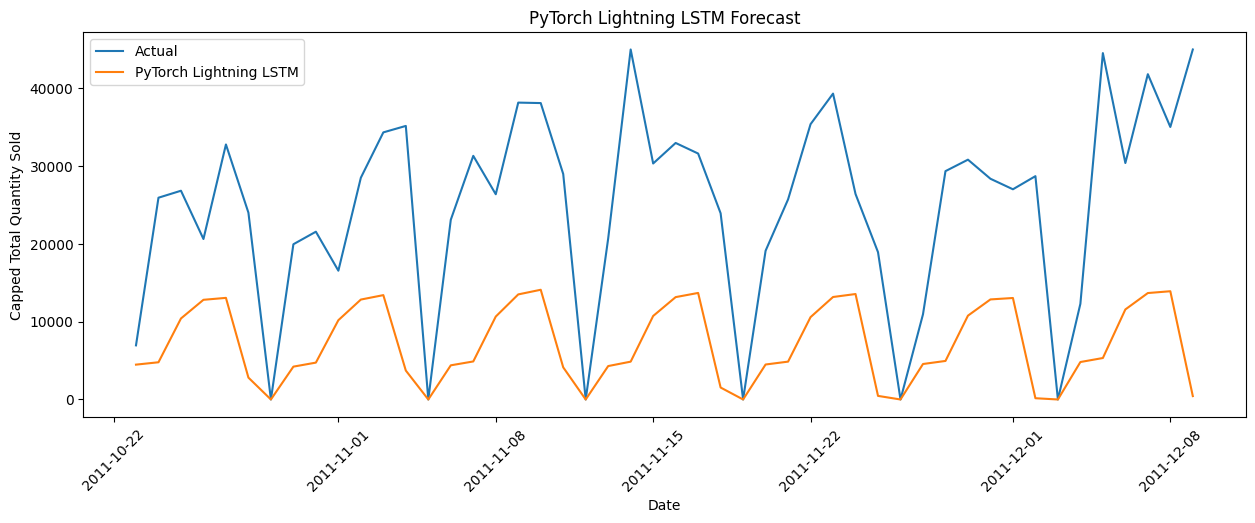

In [175]:
pl_lstm_dates = pl_df["date"].iloc[-len(pl_lstm_actual):]

plt.figure(figsize=(15, 5))

plt.plot(
    pl_lstm_dates,
    pl_lstm_actual,
    label="Actual"
)

plt.plot(
    pl_lstm_dates,
    pl_lstm_predictions,
    label="PyTorch Lightning LSTM"
)

plt.title("PyTorch Lightning LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Capped Total Quantity Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

# XGBOOST

In [176]:
feature_cols = [
    "day_of_week",
    "month",
    "day",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "total_orders",
    "unique_products",
    "unique_customers"
]

target_col = "total_quantity_capped"

train_size_ml = int(len(ml_forecast_df) * 0.8)

train_ml = ml_forecast_df.iloc[:train_size_ml].copy()
test_ml = ml_forecast_df.iloc[train_size_ml:].copy()

X_train_ml = train_ml[feature_cols]
y_train_ml = train_ml[target_col]

X_test_ml = test_ml[feature_cols]
y_test_ml = test_ml[target_col]

print("X_train:", X_train_ml.shape)
print("X_test:", X_test_ml.shape)
print("Train date range:", train_ml["date"].min(), "to", train_ml["date"].max())
print("Test date range:", test_ml["date"].min(), "to", test_ml["date"].max())

X_train: (275, 14)
X_test: (69, 14)
Train date range: 2010-12-31 00:00:00 to 2011-10-01 00:00:00
Test date range: 2011-10-02 00:00:00 to 2011-12-09 00:00:00


In [177]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_train_ml,
    y_train_ml
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [178]:
xgb_predictions = xgb_model.predict(X_test_ml)

xgb_predictions = np.maximum(xgb_predictions, 0)

xgb_mae, xgb_rmse, xgb_smape = calculate_metrics(
    y_test_ml.values,
    xgb_predictions
)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("SMAPE:", xgb_smape)

XGBoost Results
MAE: 5213.747705376665
RMSE: 7207.323228483049
SMAPE: 26.383720862772698


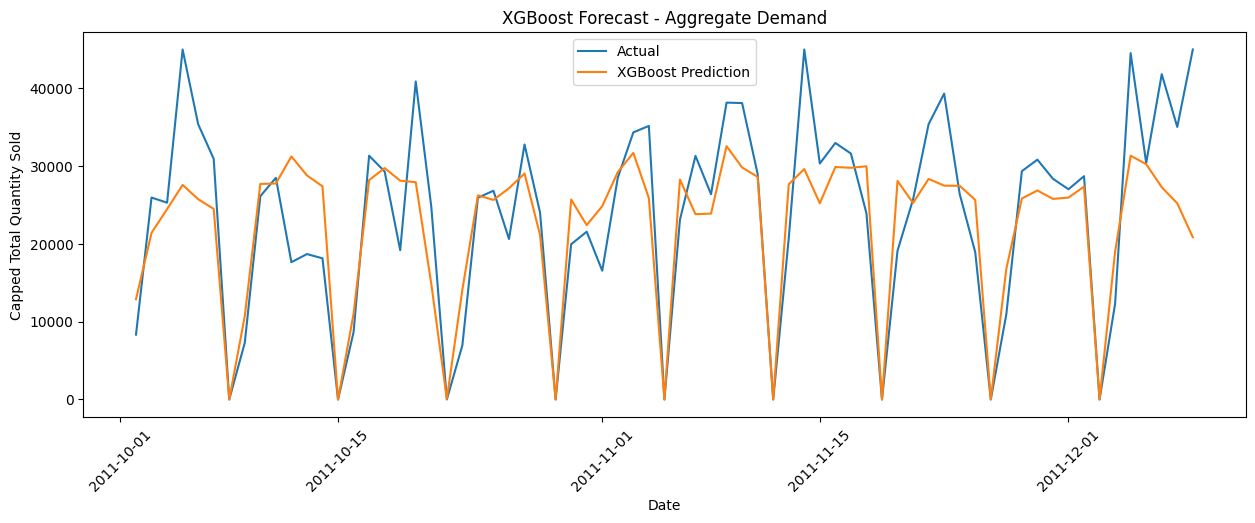

In [179]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_ml["date"],
    y_test_ml.values,
    label="Actual"
)

plt.plot(
    test_ml["date"],
    xgb_predictions,
    label="XGBoost Prediction"
)

plt.title("XGBoost Forecast - Aggregate Demand")
plt.xlabel("Date")
plt.ylabel("Capped Total Quantity Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

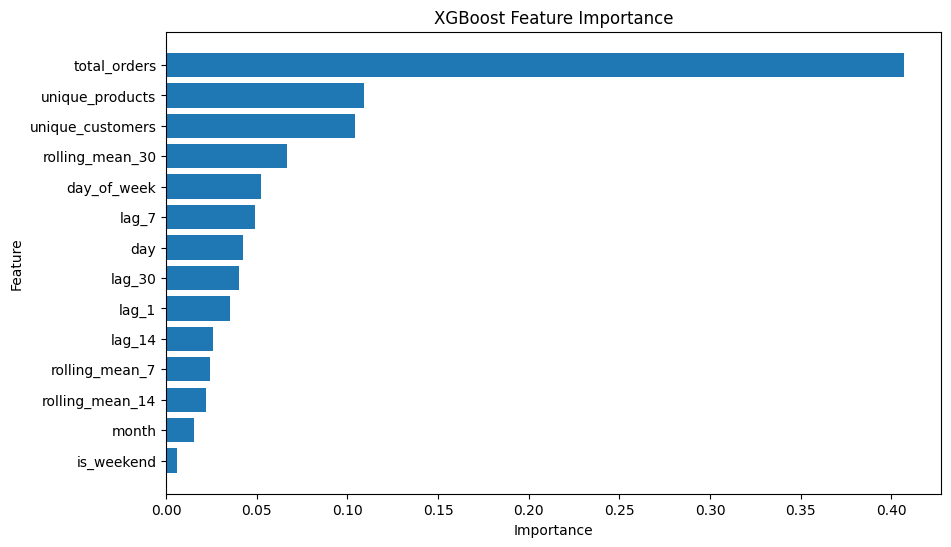

,feature,importance
11,total_orders,0.407080
12,unique_products,0.109097
13,unique_customers,0.104428
10,rolling_mean_30,0.066425
0,day_of_week,0.052512
5,lag_7,0.048888
2,day,0.042478
7,lag_30,0.040230
4,lag_1,0.035094
6,lag_14,0.025910


In [180]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

feature_importance

# TUNING XGBOOST

In [181]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_ml, y_train_ml)

print("Best Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}


In [182]:
xgb_tuned_model = random_search.best_estimator_

xgb_tuned_predictions = xgb_tuned_model.predict(X_test_ml)
xgb_tuned_predictions = np.maximum(xgb_tuned_predictions, 0)

xgb_tuned_mae, xgb_tuned_rmse, xgb_tuned_smape = calculate_metrics(
    y_test_ml.values,
    xgb_tuned_predictions
)

print("Tuned XGBoost Results")
print("MAE:", xgb_tuned_mae)
print("RMSE:", xgb_tuned_rmse)
print("SMAPE:", xgb_tuned_smape)

Tuned XGBoost Results
MAE: 5235.799493319745
RMSE: 7270.484061767093
SMAPE: 20.25598308522541


# RANDOM FOREST

In [183]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_ml, y_train_ml)

rf_predictions = rf_model.predict(X_test_ml)
rf_predictions = np.maximum(rf_predictions, 0)

rf_mae, rf_rmse, rf_smape = calculate_metrics(
    y_test_ml.values,
    rf_predictions
)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("SMAPE:", rf_smape)

Random Forest Results
MAE: 5171.217946735475
RMSE: 7260.057221799088
SMAPE: 20.343453007262273


# BLEND

In [184]:
ensemble_predictions = (
    0.7 * xgb_tuned_predictions +
    0.3 * rf_predictions
)

ensemble_mae, ensemble_rmse, ensemble_smape = calculate_metrics(
    y_test_ml.values,
    ensemble_predictions
)

print("Ensemble Results")
print("MAE:", ensemble_mae)
print("RMSE:", ensemble_rmse)
print("SMAPE:", ensemble_smape)

Ensemble Results
MAE: 5133.683994507088
RMSE: 7203.369457082754
SMAPE: 19.972942766677672


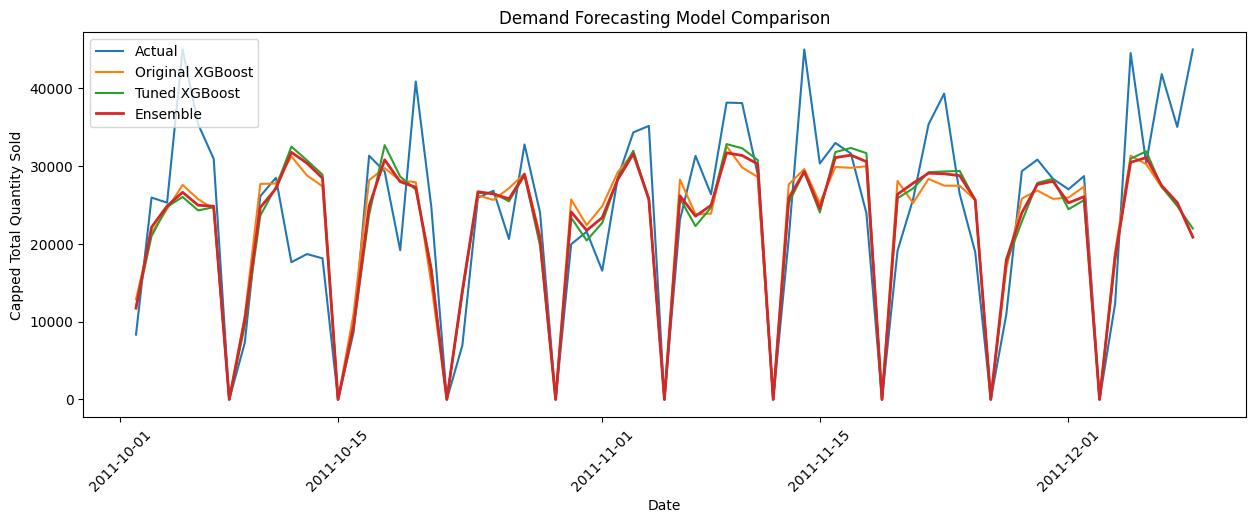

In [185]:
plt.figure(figsize=(15, 5))

plt.plot(test_ml["date"], y_test_ml.values, label="Actual")
plt.plot(test_ml["date"], xgb_predictions, label="Original XGBoost")
plt.plot(test_ml["date"], xgb_tuned_predictions, label="Tuned XGBoost")
plt.plot(test_ml["date"], ensemble_predictions, label="Ensemble", linewidth=2)

plt.title("Demand Forecasting Model Comparison")
plt.xlabel("Date")
plt.ylabel("Capped Total Quantity Sold")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [186]:
model_comparison = pd.DataFrame({
    "model": [
        "Naive Baseline",
        "Moving Average Baseline",
        "Prophet",
        "LSTM",
        "Original XGBoost",
        "Tuned XGBoost",
        "Random Forest",
        "Ensemble XGB + RF"
    ],
    "MAE": [
        naive_mae,
        ma_mae,
        prophet_mae,
        lstm_mae,
        xgb_mae,
        xgb_tuned_mae,
        rf_mae,
        ensemble_mae
    ],
    "RMSE": [
        naive_rmse,
        ma_rmse,
        prophet_rmse,
        lstm_rmse,
        xgb_rmse,
        xgb_tuned_rmse,
        rf_rmse,
        ensemble_rmse
    ],
    "SMAPE": [
        naive_smape,
        ma_smape,
        prophet_smape,
        lstm_smape,
        xgb_smape,
        xgb_tuned_smape,
        rf_smape,
        ensemble_smape
    ]
})

model_comparison = model_comparison.sort_values("SMAPE")

model_comparison

NameError: name 'lstm_mae' is not defined

The ensemble model combining Tuned XGBoost and Random Forest achieved the best performance with SMAPE of 19.97%, outperforming statistical baselines, Prophet, LSTM, and standalone tree-based models.

The dataset contains 69 zero-demand days, mainly weekends and holiday periods. These are treated as valid business non-operating/no-sales days rather than missing values. The ensemble model successfully learned this recurring pattern, which improved overall forecasting reliability.

In [ ]:
print(
    (forecast_data["total_quantity_capped"] == 0).sum()
)

69


In [ ]:
forecast_data[
    forecast_data["total_quantity_capped"] == 0
][["date","total_quantity_capped"]].head(20)

,date,total_quantity_capped
3,2010-12-04,0.0
10,2010-12-11,0.0
17,2010-12-18,0.0
23,2010-12-24,0.0
24,2010-12-25,0.0
25,2010-12-26,0.0
26,2010-12-27,0.0
27,2010-12-28,0.0
28,2010-12-29,0.0
29,2010-12-30,0.0


In [ ]:
import joblib

final_forecast_results = pd.DataFrame({
    "date": test_ml["date"],
    "actual_demand": y_test_ml.values,
    "original_xgboost_prediction": xgb_predictions,
    "tuned_xgboost_prediction": xgb_tuned_predictions,
    "random_forest_prediction": rf_predictions,
    "ensemble_prediction": ensemble_predictions
})

final_forecast_results.to_csv(
    "../data/processed/demand_forecast_results.csv",
    index=False
)

model_comparison.to_csv(
    "../data/processed/demand_forecast_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "../data/processed/xgboost_forecast_feature_importance.csv",
    index=False
)

joblib.dump(xgb_tuned_model, "../models/tuned_xgboost_demand_forecast_model.pkl")
joblib.dump(rf_model, "../models/random_forest_demand_forecast_model.pkl")

print("Final demand forecasting outputs saved successfully.")

Final demand forecasting outputs saved successfully.


In [ ]:
print("Demand Forecasting Completed Successfully!")

print("\nBest Model: Ensemble XGBoost + Random Forest")
print("Best MAE:", round(ensemble_mae, 2))
print("Best RMSE:", round(ensemble_rmse, 2))
print("Best SMAPE:", round(ensemble_smape, 2), "%")

print("\nModel Comparison:")
print(model_comparison)

print("\nTop 5 Important Features:")
print(feature_importance.head(5))

print("\nFiles Saved:")
print("1. data/processed/demand_forecast_results.csv")
print("2. data/processed/demand_forecast_model_comparison.csv")
print("3. data/processed/xgboost_forecast_feature_importance.csv")
print("4. models/tuned_xgboost_demand_forecast_model.pkl")
print("5. models/random_forest_demand_forecast_model.pkl")

Demand Forecasting Completed Successfully!

Best Model: Ensemble XGBoost + Random Forest
Best MAE: 5133.68
Best RMSE: 7203.37
Best SMAPE: 19.97 %

Model Comparison:
                     model           MAE          RMSE      SMAPE
7        Ensemble XGB + RF   5133.683995   7203.369457  19.972943
5            Tuned XGBoost   5235.799493   7270.484062  20.255983
6            Random Forest   5171.217947   7260.057222  20.343453
4         Original XGBoost   5213.747705   7207.323228  26.383721
1  Moving Average Baseline   9817.898571  12549.801714  53.126991
0           Naive Baseline  11003.230000  13091.293327  61.453352
3                     LSTM  12000.876953  13916.302957  66.580986
2                  Prophet  13196.277969  16941.376428  83.191255

Top 5 Important Features:
             feature  importance
11      total_orders    0.407080
12   unique_products    0.109097
13  unique_customers    0.104428
10   rolling_mean_30    0.066425
0        day_of_week    0.052512

Files Saved:
1.